In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import roc_curve

In [3]:
df = pd.read_csv("train(1).csv")

In [4]:
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [5]:
df.shape

(200000, 202)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


In [7]:
df.isnull().sum().sum()

0

In [8]:
df.columns

Index(['ID_code', 'target', 'var_0', 'var_1', 'var_2', 'var_3', 'var_4',
       'var_5', 'var_6', 'var_7',
       ...
       'var_190', 'var_191', 'var_192', 'var_193', 'var_194', 'var_195',
       'var_196', 'var_197', 'var_198', 'var_199'],
      dtype='object', length=202)

In [9]:
df['target'].value_counts()

target
0    179902
1     20098
Name: count, dtype: int64

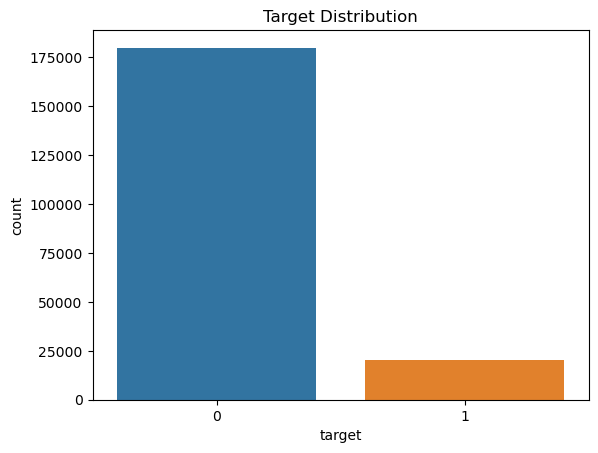

In [10]:
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

In [11]:
X = df.drop(['ID_code', 'target'], axis=1)
y = df['target']

In [12]:
X.head()

,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,-4.9193,5.9525,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,-5.8609,8.2450,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,6.2654,7.6784,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [16]:
lr_pred = lr.predict(X_test_scaled)

In [17]:
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Accuracy: 0.9131
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     35903
           1       0.70      0.27      0.39      4097

    accuracy                           0.91     40000
   macro avg       0.81      0.63      0.67     40000
weighted avg       0.90      0.91      0.90     40000



In [18]:
dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Accuracy: 0.895075
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     35903
           1       0.38      0.04      0.07      4097

    accuracy                           0.90     40000
   macro avg       0.64      0.51      0.51     40000
weighted avg       0.85      0.90      0.85     40000



In [19]:
rf = RandomForestClassifier(
    n_estimators=20,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.790625
              precision    recall  f1-score   support

           0       0.94      0.82      0.88     35903
           1       0.25      0.54      0.34      4097

    accuracy                           0.79     40000
   macro avg       0.60      0.68      0.61     40000
weighted avg       0.87      0.79      0.82     40000



In [20]:
rf_prob = rf.predict_proba(X_test)[:, 1]
print("ROC AUC Score:", roc_auc_score(y_test, rf_prob))

ROC AUC Score: 0.762738264114688


In [21]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.913100
1,Decision Tree,0.895075
2,Random Forest,0.790625


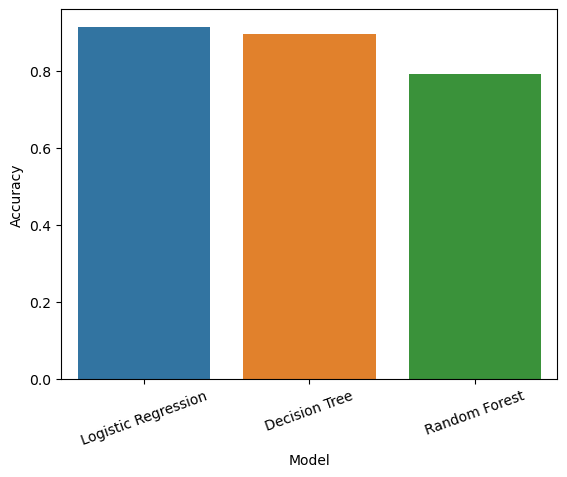

In [22]:
sns.barplot(x='Model', y='Accuracy', data=results)
plt.xticks(rotation=20)
plt.show()

In [23]:
best_model = results.sort_values(by='Accuracy', ascending=False)
best_model

,Model,Accuracy
0,Logistic Regression,0.913100
1,Decision Tree,0.895075
2,Random Forest,0.790625


In [24]:
predictions = pd.DataFrame({
    'Actual': y_test,
    'Predicted': rf_pred
})

predictions.to_csv("customer_transaction_predictions.csv", index=False)
print("CSV file saved successfully")

CSV file saved successfully


In [25]:
conn = sqlite3.connect("customer_transaction.db")

In [26]:
df.to_sql("transactions", conn, if_exists="replace", index=False)

200000

In [27]:
query = """
SELECT target, COUNT(*) AS total_customers
FROM transactions
GROUP BY target
"""

sql_result = pd.read_sql(query, conn)
sql_result

,target,total_customers
0,0,179902
1,1,20098


In [28]:
query = """
SELECT COUNT(*) AS total_customers
FROM transactions
"""
pd.read_sql(query, conn)

,total_customers
0,200000


In [29]:
query = """
SELECT COUNT(*) AS will_transact
FROM transactions
WHERE target = 1
"""
pd.read_sql(query, conn)

,will_transact
0,20098


In [30]:
query = """
SELECT 
    ROUND(
        SUM(target)*100.0 / COUNT(*), 2
    ) AS transaction_rate
FROM transactions
"""
pd.read_sql(query, conn)

,transaction_rate
0,10.05


In [31]:
import os

print(os.path.expanduser("~"))

C:\Users\jyoti


In [33]:
predictions.to_csv(r"C:\Users\jyoti\OneDrive\Desktop\Datamites\CustTranPred\customer_transaction_predictions.csv", index=False)
print("Saved successfully")

Saved successfully
